In [24]:
# import pickle

# pose = True
# with open("data.pkl", "wb") as f:
#     pickle.dump(pose, f)

# with open("data.pkl", "rb") as f:
#     pose = pickle.load(f)
# pose

In [151]:
# from langchain_ollama.llms import OllamaLLM
from langchain_ollama.chat_models import ChatOllama

In [ ]:
from config import chat_model, exercises, GROQ_API_KEY, USE_MODEL
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema import HumanMessage, AIMessage
import os
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque
import threading
import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=UserWarning, message="RNN module weights are not part of.*")


In [113]:
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

In [320]:

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

prompt_template = ChatPromptTemplate([
        ("system", """ you will be provided with angles of left knee and right knee of a patient undergoing physiotherapy. you will get angles of 3 frame runs,
         where each frame run is of 5 frames and 2 columns(left knee, right knee). the patient is doing squats.
         dont tell about the predicted coordinates and frame runs or give the user the predicted coordinates, thats just for your reference.
         you have to tell the user what is wrong in their form and how can they fix it. keep your answer concise. you have to answer in the following format.
         NOTE: do not even give the angle values or frame values. focus on keeping answer as short as possible
         Incorrect: what is wrong about my current form
         Suggestion: how can i improve my current form 
        """),
        # ("system", """
        #     You will be given left and right knee angles for one patient in physiotherapy across 3 frame runs (each run has 5 frames, 2 columns: left knee, right knee).
        #     Use this to analyze form.
        #     **Do not mention** angles, frame numbers, frame runs or predicted values in your response.
        #     Respond concisely in this format and nothing else apart from this:

        #     Incorrect: [What's wrong with the form]
        #     Suggestion: [How to improve it]
        # #     """),
        ("user", "{question}")
    ])
llm_model = {"1":"llama-3.1-8b-instant",
             "2":"meta-llama/llama-4-maverick-17b-128e-instruct",
             "3": "gemma2-9b-it"}


llm = ChatGroq(model=llm_model.get("1"))
# llm = ChatOllama(model="gemma3:1b")

In [321]:
def get_angles_to_calculate(landmarks, mp_pose):
    # Define angles to calculate
    angles_to_calculate = {
        "right_elbow_right_shoulder_right_hip": [
            [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
        ],
        "left_elbow_left_shoulder_left_hip": [
            [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
        ],
        "right_knee_mid_hip_left_knee": [
            [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
            [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
            (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
            [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
        ],
        "right_hip_right_knee_right_ankle": [
            [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
        ],
        "left_hip_left_knee_left_ankle": [
            [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
        ],
        "right_wrist_right_elbow_right_shoulder": [
            [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
            [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
            landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
        ],
        "left_wrist_left_elbow_left_shoulder": [
            [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
            [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
            landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
        ],
    }

    return angles_to_calculate

import pickle
def save_pickle_file(pose):
    with open("data.pkl", "wb") as f:
        pickle.dump(pose, f)

def load_pickle_file():
    with open("data.pkl", "rb") as f:
        pose = pickle.load(f)
        return pose

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    """Calculate angle between three points."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ab, bc = b - a, c - b
    cosine_angle = np.dot(ab, bc) / (np.linalg.norm(ab) * np.linalg.norm(bc))
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def save_llm_feedback(current_feedback):
    feedback_file_path = "llm_feedback.pkl"

    if os.path.exists(feedback_file_path):
        with open(feedback_file_path, "rb") as f:
            feedback_history = pickle.load(f)
    else:
        feedback_history = []
    
    feedback_history.append(current_feedback)
    
    with open(feedback_file_path, "wb") as f:
        pickle.dump(feedback_history, f)

def load_llm_feedback():
    feedback_file_path = "llm_feedback.pkl"

    if os.path.exists(feedback_file_path):
        with open(feedback_file_path, "rb") as f:
            feedback_history = pickle.load(f)
    return feedback_history

In [322]:
def llm_feedback(llm, prompt_template, run_buffer):
    user_input = f"""predicted = {run_buffer[0]}, {run_buffer[0]}, {run_buffer[0]} \n 
                     actual = {run_buffer[1]}, {run_buffer[1]}, {run_buffer[1]}"""
    format_prompt = prompt_template.format(question=user_input)
    response = llm.invoke(format_prompt).content
    save_llm_feedback(response)

In [256]:


def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_path/model_squats_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended, 
            # later forms a pair of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[list(pred[3:5]) for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [[list(real[3:5])for real in group[1]] for group in predicted_vs_real_storage]  

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

Calculated Angles: [32.82307399907824, 22.493026352267414, 20.65285239234859, 170.8923904202933, 175.15181650259606, 165.5358816321698, 169.2055752204606]
Calculated Angles: [34.34244741157324, 21.687974662035295, 30.823435318739755, 167.39716293161945, 156.02159103046455, 164.93890609225363, 168.1752853599107]
Calculated Angles: [34.91894383402937, 21.284981243272984, 34.28180564160521, 168.85443384684226, 149.61455871106958, 165.96840168481464, 167.8502893605825]
Calculated Angles: [35.21815192012466, 21.372779076069914, 29.508243297013205, 169.2197752940152, 156.82190425380492, 165.168416012541, 167.7359267792131]
Calculated Angles: [36.062228328914216, 21.14249389737268, 32.497624655993256, 166.6618011919483, 153.67100977197777, 163.70313027583225, 168.4258301413465]
Calculated Angles: [38.86493511835369, 30.96806176194936, 30.341981394316978, 169.06095105423805, 158.041838612354, 160.30617792418266, 179.99858452873687]
Calculated Angles: [41.35860241801065, 60.84177794999598, 159.

In [351]:
# updated model squats

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
INPUT_WINDOW= 20
OUTPUT_WINDOW = 5
PRED_FREQ = 5
pose_sequences = deque(maxlen=INPUT_WINDOW)
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag (false-during prediction, true-calculating real time values)
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
wrong_buffer = []
right_buffer = []
threshold=300
pose = None 
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
exercise  = exercises
BUFFER_LEN = 3
LLM_COOLDOWN = 10
cooldown_count = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
df = pd.DataFrame()

# Define mapping exercise to model
model_paths = {
    "squats": r"model_path/model_squats_scripted.pt",
    "pushups": r"model_path/model_pushup_scripted.pt",
    # Add more mappings here if needed
}

# Load model dynamically
model_path = model_paths.get("squats")

lstm_model = torch.jit.load(model_path)
lstm_model.to(device) 
lstm_model.eval()

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7])) 

cap = cv2.VideoCapture(0)  # Access webcam

with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=1) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        # image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                    mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                    mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate

            angles_to_calculate = get_angles_to_calculate(landmarks, mp_pose)
            
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            # print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == OUTPUT_WINDOW:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[list(pred[3:5]) for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [[list(real[3:5])for real in group[1]] for group in predicted_vs_real_storage]  

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> BUFFER_LEN:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > BUFFER_LEN:
                        loss_buffer.pop(0)

                    if USE_MODEL:
                        cooldown_count += 1
                        print(cooldown_count)
                        if all(x > 500 for x in loss_buffer):
                            print("WRONG POSE******************************************************************")
                            pose_status = False
                            wrong_buffer.append(run_buffer)
                            focus_len = len(focus_angles)
                            if focus_len > 20 and cooldown_count > LLM_COOLDOWN:
                                cooldown_count = 0
                                t1 = threading.Thread(target=llm_feedback, args=(llm, prompt_template, run_buffer))
                                t1.start()
                                # llm_output = llm_feedback(llm, prompt_template, run_buffer)
                                # print(focus_len,llm_output)
                            save_pickle_file(pose_status)
                            

                        else:
                            # print("RIGHT POSE###############################################################")
                            pose_status = True
                            right_buffer.append(run_buffer)
                            save_pickle_file(pose_status)

                        true_count = sum(1 for x in loss_buffer if x <= 500)
                        false_count = sum(1 for x in loss_buffer if x > 500)
                        # add_session_accuracy(df, loss_buffer)
                        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == INPUT_WINDOW  and not collecting_real_time:# if flag is false
                INPUT_WINDOW_degrees = scaler.inverse_transform(np.array(pose_sequences))
                # print(f" Input Window (Degrees) Before Prediction:\n{INPUT_WINDOW_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                # print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[PRED_FREQ:], maxlen=INPUT_WINDOW)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:PRED_FREQ])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # # i have not focused on camera written display 
                # for i, angle in enumerate(predicted_angles[0]):
                #     cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                tempo = load_pickle_file()
                if tempo:
                    cv2.putText(image, f"Bool Value: {tempo}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                else:
                    cv2.putText(image, f"Bool Value: {tempo}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

1
WRONG POSE******************************************************************
2
WRONG POSE******************************************************************
3
WRONG POSE******************************************************************
4
WRONG POSE******************************************************************
5
WRONG POSE******************************************************************
6
WRONG POSE******************************************************************
7
WRONG POSE******************************************************************
8
WRONG POSE******************************************************************
9
WRONG POSE******************************************************************
10
WRONG POSE******************************************************************
11
WRONG POSE******************************************************************
12
WRONG POSE******************************************************************
13
WRONG POSE************************************

In [352]:
load_llm_feedback()

['Incorrect: Your knees are not bending deep enough, indicated by the large angle between the left and right knee.\nSuggestion: Try to lower yourself deeper into the squat, keeping your back straight and your weight in your heels.',
 'Incorrect: Your left knee is not bending enough and your right knee is not tracking the movement of your left knee properly. Your form is also not consistent throughout the three frame runs.\n\nSuggestion: Focus on bending your left knee more and keep your right knee in line with your left knee, ensuring that they move together throughout the squat. Practice maintaining a consistent form by paying close attention to your body positioning.',
 'Incorrect: Your left and right knee angles are much too high throughout the squat, indicating a poor range of motion and potentially putting unnecessary strain on your joints.\nSuggestion: Focus on lowering your body more deeply into the squat, keeping your knees in a more neutral position and your weight evenly dist

In [ ]:
#PUSHUP
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_pushup_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            all_angle_keys = list(angles_to_calculate.keys())
            focus_angle_keys = [
                "right_elbow_right_shoulder_right_hip",
                "left_elbow_left_shoulder_left_hip",
                "right_wrist_right_elbow_right_shoulder",
                "left_wrist_left_elbow_left_shoulder"
            ]
            focus_indices = [all_angle_keys.index(key) for key in focus_angle_keys]
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[ [pred[i] for i in focus_indices] for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [ [[real[i] for i in focus_indices] for real in group[1]] for group in predicted_vs_real_storage ]

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

In [353]:
len(focus_angles)

234

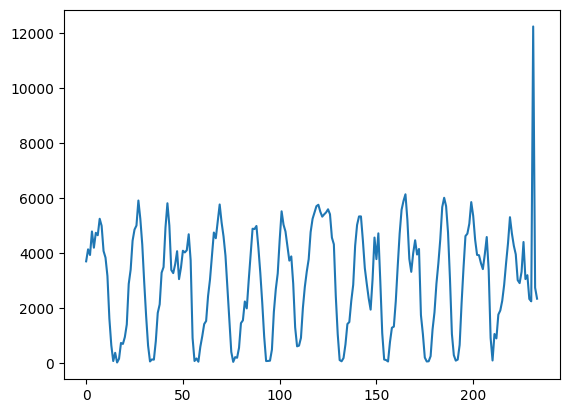

In [354]:
import matplotlib.pyplot as plt  
plt.plot(realtime_loss)

In [331]:
for index, loss in enumerate(realtime_loss):
    print(index, int(loss))

0 1506
1 3809
2 4192
3 5121
4 4663
5 2244
6 1387
7 1292
8 2506
9 49
10 531
11 1127
12 2795
13 2278
14 2776
15 3147
16 4276
17 5375
18 5315
19 3796
20 1428
21 217
22 216
23 626
24 2109
25 2144
26 2772
27 4064
28 5164
29 5625
30 4781
31 3340
32 222
33 1976
34 296
35 282
36 627
37 1351
38 2283
39 3722
40 4024
41 2139
42 901
43 610
44 249
45 37
46 318
47 1253
48 865
49 6311
50 4965
51 1734
52 667
53 9
54 44
55 154
56 262
57 467
58 2035
59 3295
60 4486
61 2638
62 3825
63 383
64 122
65 468
66 191
67 91
68 1300
69 1455
70 4937
71 2968
72 3238
73 106
74 578
75 43
76 1790
77 1193
78 3352
79 4853
80 3169
81 4483
82 489
83 68
84 175
85 69
86 771
87 1437
88 4257
89 3079
90 3110
91 1358
92 1415
93 6751


In [332]:
column = 20
user_input = f"""predicted = {focus_angles[column][0]}, {focus_angles[column+1][0]}, {focus_angles[column+2][0]} \n 
                     actual = {focus_angles[column][1]}, {focus_angles[column+1][1]}, {focus_angles[column+2][1]}"""

format_prompt = prompt_template.format(question=user_input)
response = llm.invoke(format_prompt).content
print(response)

Incorrect: Your knees are not tracking the same movement pattern, indicating uneven strength or coordination between the left and right knees. Your right knee is bending too much, which can put unnecessary stress on your knee joint.

Suggestion: Focus on maintaining proper knee alignment and engage your core muscles to stabilize your lower body. Try to keep your knees in line with your toes and avoid letting your right knee bend excessively.


In [355]:
# threshold = 250 for 3 or more iterations
import pandas as pd
# pd.DataFrame(focus_angles[0][1])
# len(focus_angles)
column = 38
pre = focus_angles[column][0] #pred
act = focus_angles[column][1] #real
# pd.DataFrame({"predicted": pre,"actual":act})
pre, act, realtime_loss[column]

([[62.366734, 60.96714],
  [66.458916, 68.56064],
  [69.070724, 73.382286],
  [72.7941, 79.08278],
  [75.24624, 82.10329]],
 [[25.980135469989445, 28.570581410244547],
  [25.74479063812335, 27.669790800817943],
  [25.117723933262305, 25.347064967957817],
  [25.357241562213066, 24.908804504013364],
  [23.415409502971112, 23.300701880772422]],
 2127.1725352491944)

In [56]:
import torch
import torch.nn as nn
# column = 58
pre = focus_angles[column][0]
act = focus_angles[column][1]

mae_loss = nn.MSELoss()
loss = mae_loss(torch.tensor(pre),torch.tensor(act))
loss.item()

86.04602366181794

In [17]:
focus_angles[0][1]

[[149.60025066548806, 141.95205928746108],
 [133.08903912145135, 129.68786948933172],
 [134.24730774946974, 131.74074931818853],
 [147.18619993456184, 143.52510528452706],
 [152.57820957623167, 149.81233207017135]]

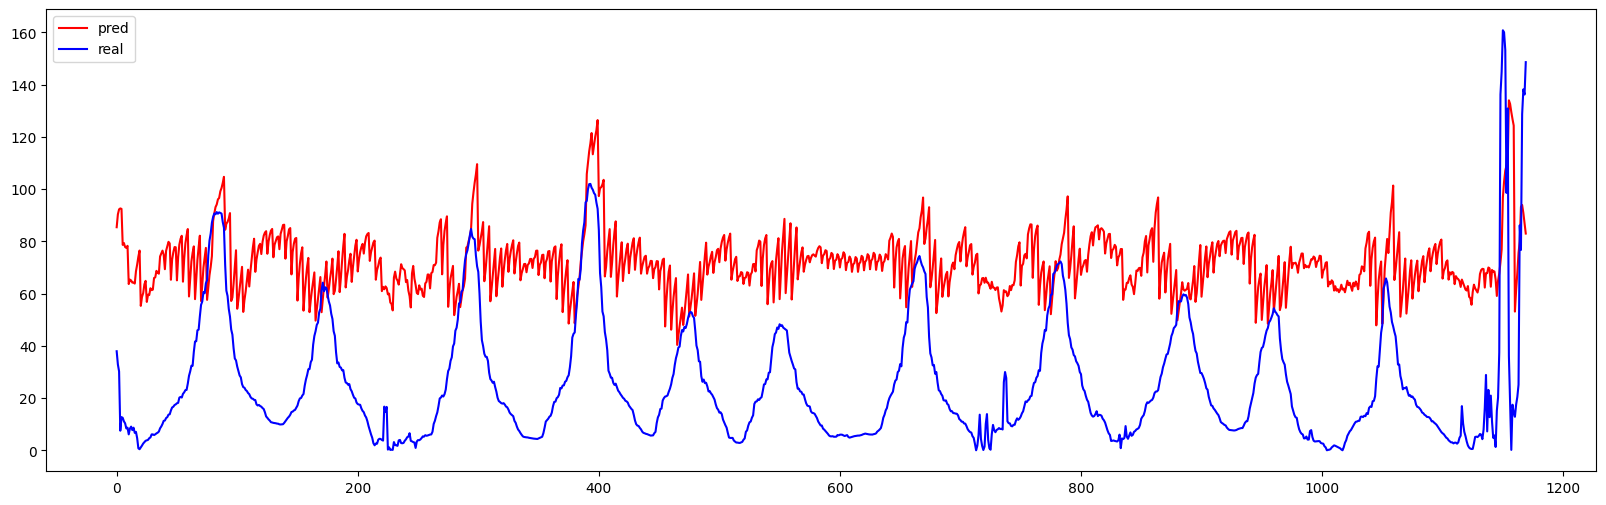

In [356]:
left_knee_list_real = []
for run in focus_angles:
    for angle in run[1]:
        left_knee_list_real.append(angle[0])

left_knee_list_pred = []
for run in focus_angles:
    for angle in run[0]:
        left_knee_list_pred.append(angle[0])
        
plt.figure(figsize=(20, 6))
plt.plot(left_knee_list_pred, label="pred", color="red")
plt.plot(left_knee_list_real, label="real", color="blue")
plt.legend()
plt.show()

# Make Basic Detection

In [3]:
# Getting video feed
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()

        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False 

        # Make detection
        results = pose.process(image)
        
        # Recolor back to BGR
        image.flags.writeable = True 
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
            print(landmarks)
        except:
            pass

        # Rendering
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2),
                                  )

        cv2.imshow('Raw Webcam Feed', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# Extract keypoints from a video 

In [23]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque
import pandas as pd

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

# lstm_model = torch.jit.load(r'model_path\model_squats_scripted.pt')#for linux relative path
# lstm_model.to(device) 
# lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(r"tanmay pushups\VID-20250404-WA0035.mp4")
# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
count = 0
df = pd.DataFrame(columns=["frame_order","right_elbow_right_shoulder_right_hip", "left_elbow_left_shoulder_left_hip", "right_knee_mid_hip_left_knee", "right_hip_right_knee_right_ankle",
                            "left_hip_left_knee_left_ankle", "right_wrist_right_elbow_right_shoulder", "left_wrist_left_elbow_left_shoulder"])
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }
            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            # print(f"Calculated Angles: {angles}")
            # print(angles)
            angles = [int(count)] + angles
            df.loc[count] = angles
            count += 1

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

In [24]:
df["frame_order"] = df["frame_order"].astype(int)
df.head()

,frame_order,right_elbow_right_shoulder_right_hip,left_elbow_left_shoulder_left_hip,right_knee_mid_hip_left_knee,right_hip_right_knee_right_ankle,left_hip_left_knee_left_ankle,right_wrist_right_elbow_right_shoulder,left_wrist_left_elbow_left_shoulder
0,0,69.131801,69.488062,50.157357,171.690244,164.791668,167.101954,173.693773
1,1,68.232373,70.325272,51.711561,171.501964,163.395162,166.837190,172.439141
2,2,68.654636,72.166386,52.438742,171.149540,161.246770,165.752170,173.604748
3,3,69.339805,73.726076,52.253583,169.770035,162.323658,166.303944,174.157210
4,4,69.117058,75.723440,52.712997,169.468358,164.742487,166.811494,176.205446


In [25]:
df.to_csv('tantest2.7.csv', index=False)

In [17]:
video_frame_count = 1061  # Number of frames per video

# Generate video_id and frame_order for the original data
video_id = (df['frame_order'] // video_frame_count).astype(int)
df['video_id'] = video_id

# Reorder columns to make video_id the first column
column_order = ['video_id', 'frame_order'] + [col for col in df.columns if col not in ['video_id', 'frame_order']]
df = df[column_order]

# Create 20 duplicates and update video_id sequentially
all_data = []
for i in range(20):
    temp_df = df.copy()
    temp_df['video_id'] = temp_df['video_id'] + i
    all_data.append(temp_df)

df_final = pd.concat(all_data, ignore_index=True)
df_final.to_csv('new_squats.csv', index=False)


In [ ]:
# df.to_csv('hakli_data.csv', index=False)

In [ ]:
# df_repeated = pd.concat([df] * 20, ignore_index=True)
# df_repeated.to_csv('hakli_repeat.csv', index=False)

In [ ]:
# df_repeated.head()

,frame_order,right_elbow_right_shoulder_right_hip,left_elbow_left_shoulder_left_hip,right_knee_mid_hip_left_knee,right_hip_right_knee_right_ankle,left_hip_left_knee_left_ankle,right_wrist_right_elbow_right_shoulder,left_wrist_left_elbow_left_shoulder,video_id
0,0,20.860193,16.034512,28.925374,177.344150,177.770924,176.154408,161.086469,0
1,1,19.777086,15.933075,28.994755,177.597040,178.010313,178.760230,161.040051,0
2,2,18.745600,15.983862,28.944070,177.761838,178.020727,178.572138,161.884094,0
3,3,18.198449,16.337870,28.891036,178.172410,177.808015,177.528918,161.771075,0
4,4,17.828334,16.618230,29.056345,178.276824,177.621667,177.073543,161.813922,0


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

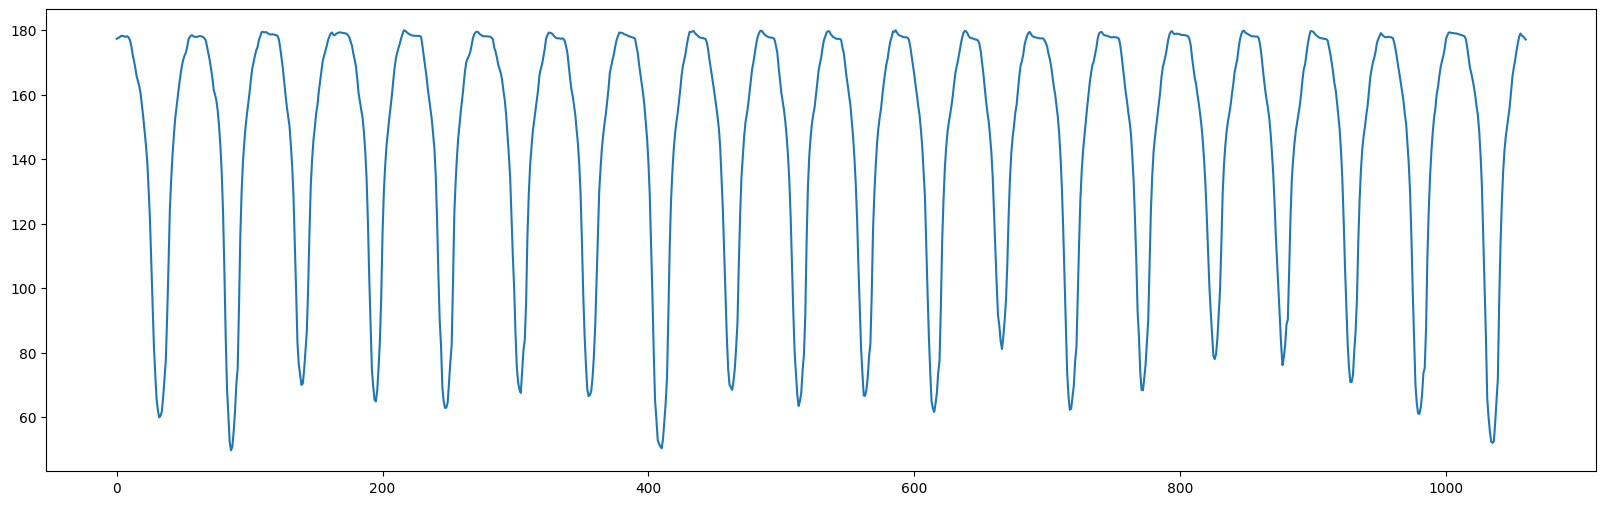

In [7]:
import matplotlib.pyplot as plt  
plt.figure(figsize=(20,6))
plt.plot(df.iloc[:,4])
plt.plot

In [101]:
data = [40.292152280872415,
 41.76803187491497,
 32.0649883255575,
 175.04658384066218,
 178.01065096826343,
 23.947889496301663,
 17.870666463195903]

df = pd.DataFrame(columns=["1","2","3","4","5","6","7"])
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [116]:
df.loc[len(df)] = data
df

,1,2,3,4,5,6,7
0,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
1,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
2,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
3,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
4,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
5,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
6,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
7,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
8,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666
9,40.292152,41.768032,32.064988,175.046584,178.010651,23.947889,17.870666


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import sys

mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

cap = cv2.VideoCapture(sys.argv[1])

if cap.isOpened() == False:
    print("Error opening video stream or file")
    raise TypeError

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

outdir, inputflnm = sys.argv[1][:sys.argv[1].rfind(
    '/')+1], sys.argv[1][sys.argv[1].rfind('/')+1:]
inflnm, inflext = inputflnm.split('.')
out_filename = f'{outdir}{inflnm}_annotated.{inflext}'
out = cv2.VideoWriter(out_filename, cv2.VideoWriter_fourcc(
    'M', 'J', 'P', 'G'), 10, (frame_width, frame_height))

while cap.isOpened():
    ret, image = cap.read()
    if not ret:
        break

    image = cv2.cvtColor(cv2.flip(image, 1), cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = pose.process(image)

    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    mp_drawing.draw_landmarks(
        image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    out.write(image)
pose.close()
cap.release()
out.release()


# 2. Determining Joints

<img src="https://i.imgur.com/3j8BPdc.png" style="height:300px" >

In [4]:
landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value]

NameError: name 'landmarks' is not defined

In [ ]:
landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value]

x: 1.01653159
y: 0.86054343
z: -1.10317266
visibility: 0.545346856

# 3. Calculate Angles

In [5]:
def calculate_angle(a,b,c):
    a = np.array(a) # First
    b = np.array(b) # Mid
    c = np.array(c) # End
    
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    
    if angle >180.0:
        angle = 360-angle
        
    return angle 

In [6]:
shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
elbow = [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x,landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
wrist = [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x,landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y]


NameError: name 'landmarks' is not defined

In [7]:
shoulder, elbow, wrist

NameError: name 'shoulder' is not defined

In [ ]:
calculate_angle(shoulder, elbow, wrist)

158.37397025964307

# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()
